# CDState: end-to-end analysis

In this tutorial, we show how to run CDState for a range of components, select the best number of components for analysis and characterize identified malignant states. 

### Loading packages
First, let's load necessary packages

In [1]:
%load_ext rpy2.ipython
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
import CDState_base as cd
import pandas as pd
import copy
import numpy as np
import sklearn, random

As in the `CDState_analysis.ipynb` tutorial, we will use bulkified glioblastoma datasets (available in the `data` directory)


In [2]:
root = Path.cwd().parent
file_path = root / "data" / "bulkified_cancer" / "GBM"

data = pd.read_csv(file_path / "Neftel_GBM_SS2_bulkified_sum_v2.txt", index_col=0,sep=',',header=0)
proportions = pd.read_csv(file_path / "Neftel_GBM_SS2_proportions_sum_v2.txt", index_col=0,sep=',',header=0)

This time we will use ground-truth purity of the samples, but for instructions on how to calculate purity values if you don't have them, see `CDState_analysis.ipynb` notebok. 

In [3]:
purity = proportions.loc['Purity',:]
purity.rename(index="purity", inplace=True)
purity.index = data.columns
purity

MGH100    1.000000
MGH101    0.765000
MGH102    0.605948
MGH104    1.000000
MGH105    0.624606
MGH106    0.680000
MGH110    0.837535
MGH113    0.823077
MGH115    0.969697
MGH121    0.983165
MGH122    0.732601
MGH124    0.883784
MGH125    0.832080
MGH128    0.864130
MGH129    0.989583
MGH136    0.991342
MGH143    0.996337
MGH151    0.742331
MGH152    0.995595
MGH66     0.997706
BT1160    1.000000
BT1187    0.036530
BT749     0.993691
BT771     0.967552
BT786     0.985714
BT830     1.000000
BT920     0.956667
Name: purity, dtype: float64

In real-case use, true number of malignant cell states and necessary components to identify them is unknown, therefore we recomment **running CDState for a range of components**, at least 3 - with the goal to identify at least 2 malignant cell states. At the same time, the number of components should not be too high to avoid identifying sources which are sample-specific (i.e., showing high proportions in only 1 sample). Therefore, we recommend running CDState **for range of 2 to n/2 components**, where n is the number of input samples.

In addition, CDState is a non-deterministic method - that is, the output will be different depending on the initialization of sources. To identify the most robust output for downstream analysis, we recommend **running CDState multiple times with different initialization**, for the specific number of components. Below, we provide code to do that:

In [16]:
import time
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans

output_path = Path.cwd().parent / "notebooks" / "GBM_example"

def multi_run(df, kmin, kmax, purity, output_path, output_prefix, niter):
    start_time = time.time()
    for k in range(kmin, kmax+1):
        print("Estimating for k = ", str(k))
        for i in range(niter):
            print(i)
            cn = cd.CDState(df, num_bases=k, global_round = False)
            cn.prepare_data()
            cosim = cosine_similarity(cn.data.T)
            km = KMeans(n_clusters=k, n_init="auto", init="random").fit(cosim)
            km_labels = km.labels_
            initial_sources_idx = [random.sample(np.where(km_labels == y)[0].tolist(),1)[0] for y in range(k)]
            initial_sources = cn.data[:,initial_sources_idx]
            cn.W = copy.copy(initial_sources)
            cn.W += 1e-10 #pseudocount to avoid division by 0 in the first iteration
            cn.factorize()
            print("Step 1 - done")
            cnG = cd.CDState(df, purity, global_round=True, num_bases=k, gene_list = cn.gene_list)
            cnG.prepare_data()
            cnG.W = copy.copy(cn.W)
            cnG.W += 1e-10
            cnG.H = copy.copy(cn.H)
            cnG.factorize()
            print("Step 2 - done")
            #save outputs
            wG = pd.DataFrame(cnG.W, index=cnG.gene_list)
            #cnG.infer_full() # if you wish to infer sources for the full list of genes
            #cnG.full_W.to_csv(output_path + "global_" + output_prefix + "_k" + str(k) + "_iter" + str(i) + "_full_W.csv", sep=',')
            output_proportions = output_prefix + "_k" + str(k) + "_iter" + str(i) + "_proportions.csv"
            output_sources = output_prefix + "_k" + str(k) + "_iter" + str(i) + "_sources.csv"
            output_mal = output_prefix + "_k" + str(k) + "_iter" + str(i) + "_mal.csv"
            np.savetxt(output_path / output_proportions, cnG.H, delimiter=',', header=','.join(cnG.samples))
            wG.to_csv(output_path / output_sources, sep=',')
            np.savetxt(output_path / output_mal, cnG.mal, delimiter=',')
    print("--- %s seconds ---" % (time.time() - start_time))
    return


In the function above:
- `df` is input pandas data frame with bulk expression
- `kmin` and `kmax` specify the range of components
- `purity` is a pandas data frame with 'purity' column
- `output_path` is where you want to save results from each CDState run
- `prefix` is the prefix of output files
- `niter` is the number of runs for each number of components

Let's run it for 3 to 8 components, each time for 10 times. The outputs will be saved in `notebooks/GBM_example` - you can skip the next line as it takes ~40 minutes with 2 CPUs, and use them directly in section **Select the optimal number of components**.

In [18]:
# multi_run(data, 3, 8, purity, output_path, 'GBM', 10) # UNCOMMENT if you wish to run it yourself

### Select the optimal number of components
Once CDState is finished, we can analyze the outputs to decide on the optimal number of components to use for downstream analysis. To do that, we will analyze the number of malignant states and their correlation with purity, for each number of components across the 10 runs. Specifically, for each number of components and for each run:
* identify malignant components saved in the `*mal.csv` file
* calculate the correlation between malignant abundance (sum of malignant component proportions from `*proportions.csv` file) and known sample purity (provided to CDState)
* record how many malignant components that run has.

Then for each number of components:
* find the most common malignant component count across runs
* within runs with that common malignant count, pick the run with the highest correlation as the “top run” for that k.

We do this using the code below:

In [72]:
from collections import defaultdict
import os

output_path = Path.cwd().parent / "notebooks" / "GBM_example" / "GBM"

kmax = 8
nrun = 9 # indexes from 0...9

# containers
topRunsCor = {} # to store number of the best run per 'k'
MAL_counts = {} # to store the most common number of malignant states per 'k'

ks_values = list(range(3, kmax + 1))
Purity_cors = pd.DataFrame(0.0, index=[str(k) for k in ks_values], columns=["R"])

for ks in ks_values:
    print(f"Run for k = {ks}")
    malignant_counts = np.zeros(nrun + 1, dtype=int)
    cors = np.zeros(nrun + 1, dtype=float)
    for j in range(nrun + 1):  # 0..nrun
        #print(j)
        # read proportions
        proportions_path = f"{output_path}_k{ks}_iter{j}_proportions.csv"
        proportions = pd.read_csv(proportions_path)
        proportions.columns.values[0] = proportions.columns[0].replace("# ", "")
        proportions = proportions.T
        proportions.columns = [f"S{i}" for i in range(1,proportions.shape[1]+1)]
        # read malignant file
        mal_file = f"{output_path}_k{ks}_iter{j}_mal.csv"
        try:
            # if file exists and is not empty
            if os.path.getsize(mal_file) > 0:
                mals = pd.read_csv(mal_file, header=None)
                mals_idx = mals.iloc[:, 0] + 1
                mals_cols = [f"S{str(int(i))}" for i in mals_idx]
                # data frame to calculate correlation with purity
                forMal = pd.concat([purity, proportions], axis=1)
                if len(mals_cols) > 1:
                    summed = forMal[mals_cols].sum(axis=1)
                    cor = summed.corr(forMal["purity"])
                    cors[j] = cor
                else:
                    col = mals_cols[0]
                    cor = forMal[col].corr(forMal["purity"])
                    cors[j] = cor
                malignant_counts[j] = len(mals_cols)

        except FileNotFoundError:
            continue

    # most common number of malignant components
    values, counts = np.unique(malignant_counts, return_counts=True)
    most_common_mal = int(values[np.argmax(counts)])
    # store counts
    MAL_counts[str(ks)] = malignant_counts.copy()

    # select runs with that most common malignant count
    sel_runs = np.where(malignant_counts == most_common_mal)[0]

    # restrict corrs and to those runs
    sel_cors = cors.copy()
    sel_cors = {str(idx): sel_cors[idx] for idx in sel_runs}
    #print(sel_cors.values())
    #print(max(sel_cors))
    
    # best run by correlation among selected runs
    if sel_cors:
        best_run_cor = max(sel_cors, key=sel_cors.get)  # run index as string
        # overall best across all runs
        Purity_cors.loc[str(ks), "R"] = max(sel_cors.values())
    else:
        best_run_cor = None

    topRunsCor[str(ks)] = best_run_cor # for each k, save the best run

Run for k = 3
Run for k = 4
Run for k = 5
Run for k = 6
Run for k = 7
Run for k = 8


In [73]:
topRunsCor # store the best run for each 'k'

{'3': '8', '4': '0', '5': '6', '6': '1', '7': '1', '8': '0'}

In [70]:
Purity_cors # stores correlation of the best run for each k

,R
3,0.938691
4,0.925393
5,0.940942
6,0.960783
7,0.963502
8,0.957677


In [71]:
MAL_counts # stores the number of malignant states in each run for each k

{'3': array([2, 1, 2, 2, 2, 2, 2, 2, 2, 2]),
 '4': array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2]),
 '5': array([3, 3, 3, 3, 3, 3, 3, 3, 2, 3]),
 '6': array([4, 4, 3, 4, 3, 4, 4, 3, 4, 3]),
 '7': array([4, 4, 4, 4, 4, 5, 4, 4, 5, 4]),
 '8': array([5, 5, 5, 5, 5, 5, 5, 5, 5, 5])}

To select the best number of components to analyze, we recomment plotting the best correlation of purity across runs and the number of malignant cell states identified across values of 'k':

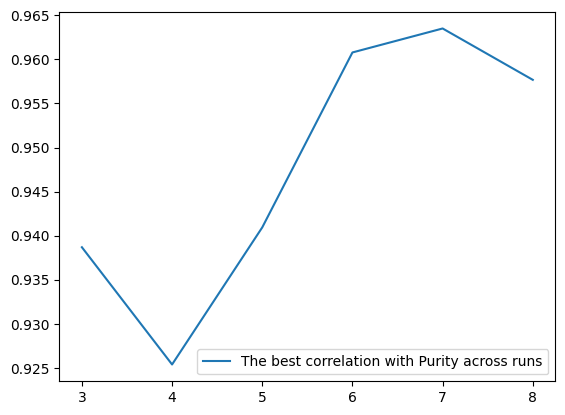

In [75]:
import matplotlib.pyplot as plt

plt.plot(Purity_cors, label="The best correlation with Purity across runs")
plt.legend()
plt.show()

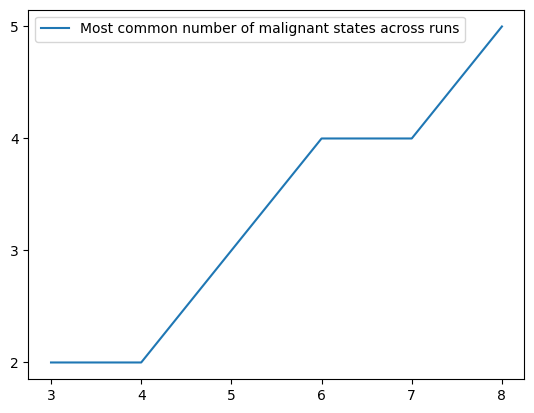

In [99]:
mal_median_df = pd.DataFrame(
    {
        "k": list(MAL_counts.keys()),
        "median": [np.median(MAL_counts[k]) for k in MAL_counts.keys()],
    }
)

# Sort by k numerically, if you want
mal_median_df["k"] = mal_median_df["k"].astype(int)
mal_median_df = mal_median_df.sort_values("k")
mal_median_df["median"] = mal_median_df["median"].round().astype(int).astype(str)
mal_median_df
plt.plot(mal_median_df['k'],mal_median_df['median'], label="Most common number of malignant states across runs")
plt.legend()
plt.show()

Based on the plots, we see that the best correlation with purity is found for seven components, which give 4 malignant cell states.

### Characterization of malignant cell states
To understand what are the biological processes enriched in the identified malignant cell states, we will use hallmark gene sets from [MsigDB](https://www.gsea-msigdb.org/gsea/msigdb/human/collections.jsp#H) and the malignant cell sources found in the best run for 7 components. 
First, we need to load state expression and proportions:

In [108]:
j = topRunsCor['7'] # run number for 7 components
ks = '7'

In [170]:
proportions_path = f"{output_path}_k{ks}_iter{j}_proportions.csv"
proportions = pd.read_csv(proportions_path)
proportions.columns.values[0] = proportions.columns[0].replace("# ", "")
#proportions.columns = proportions.columns.tolist()  # ensure it's a normal list
#proportions.columns.values[0] = proportions.columns[0].replace("X..", "")
proportions = proportions.T
proportions.columns = [f"S{i}" for i in range(1,proportions.shape[1]+1)]

sources_path = f"{output_path}_k{ks}_iter{j}_sources.csv"
sources = pd.read_csv(sources_path, index_col=0)
sources.columns = [f"S{i}" for i in range(1,sources.shape[1]+1)]

# read malignant file
mal_file = f"{output_path}_k{ks}_iter{j}_mal.csv"
mals = pd.read_csv(mal_file, header=None)
mals_idx = mals.iloc[:, 0] + 1
mals_cols = [f"S{str(int(i))}" for i in mals_idx]
mals_cols

malignant_states = sources[mals_cols]
malignant_proportions = proportions[mals_cols]

In [159]:
malignant_states.head()
#malignant_proportions.head()

,S5,S3,S1,S2
IRX4,8.923011e+00,3.302907e-14,2.946798e-07,1.071356e-26
HDC,7.469981e-01,2.105752e-13,7.917785e-10,2.403546e-13
ANKRD30BL,9.982939e+00,8.955359e-11,1.504345e-01,2.350961e-13
LOC100131289,1.478209e-11,1.541616e+00,3.919101e+00,2.222521e-13
SYTL1,9.315585e-01,2.992210e+00,1.045103e-10,4.392465e-08


In [177]:
malignant_proportions = malignant_proportions.div(
    malignant_proportions.sum(axis=1), axis=0) #calculate relative proportions

To run hallmark gene set enrichment analysis, we will use `gseapy` package:

In [ ]:
pip install gseapy lxml seaborn

In [160]:
import gseapy as gp
from gseapy.msigdb import Msigdb

In [161]:
msig = Msigdb()
hallmark_gmt = msig.get_gmt(category="h.all", dbver="2026.1.Hs")  # human hallmark gene sets

Run single-sample gene set enrichment (per state) with ssGSEA

In [162]:
enrich = gp.ssgsea(
    data=malignant_states,       # genes x states, index = gene symbols
    gene_sets=hallmark_gmt,   # hallmark gene sets
    sample_norm=True,         # normalize samples
    outdir=None,              # no files, get results in memory
    min_size=5,               # min genes in a set
    max_size=5000,            # max genes in a set
)

In [163]:
enrich.res2d # a summary of enrichment scores across hallmark gene sets

,Name,Term,ES,NES
0,S1,HALLMARK_MYC_TARGETS_V1,3135.457076,0.750714
1,S5,HALLMARK_OXIDATIVE_PHOSPHORYLATION,2865.096021,0.685982
2,S3,HALLMARK_OXIDATIVE_PHOSPHORYLATION,2800.895938,0.670611
3,S5,HALLMARK_MYC_TARGETS_V1,2723.80821,0.652154
4,S3,HALLMARK_MYC_TARGETS_V1,2665.086587,0.638094
...,...,...,...,...
195,S1,HALLMARK_TNFA_SIGNALING_VIA_NFKB,47.833999,0.011453
196,S2,HALLMARK_G2M_CHECKPOINT,-46.678551,-0.011176
197,S3,HALLMARK_ALLOGRAFT_REJECTION,-38.545992,-0.009229
198,S5,HALLMARK_INTERFERON_GAMMA_RESPONSE,35.735297,0.008556


In [164]:
# Ensure NES column is numeric
enrich.res2d["NES"] = pd.to_numeric(enrich.res2d["NES"], errors="coerce")
heat_df = enrich.res2d.pivot(index="Term", columns="Name", values="NES")

In [165]:
heat_df

Name,S1,S2,S3,S5
Term,,,,
HALLMARK_ADIPOGENESIS,0.301066,0.347206,0.416810,0.322171
HALLMARK_ALLOGRAFT_REJECTION,-0.249286,-0.114956,-0.009229,-0.150078
HALLMARK_ANDROGEN_RESPONSE,0.171419,0.266295,0.360897,0.219018
HALLMARK_ANGIOGENESIS,0.103383,0.278840,0.340782,0.157091
HALLMARK_APICAL_JUNCTION,0.081968,0.204232,0.129312,0.208567
HALLMARK_APICAL_SURFACE,0.083322,0.068531,0.057786,0.131732
HALLMARK_APOPTOSIS,0.137535,0.290777,0.349472,0.238831
HALLMARK_BILE_ACID_METABOLISM,0.190408,0.262396,0.311347,0.165629
HALLMARK_CHOLESTEROL_HOMEOSTASIS,0.257384,0.204696,0.477621,0.433861


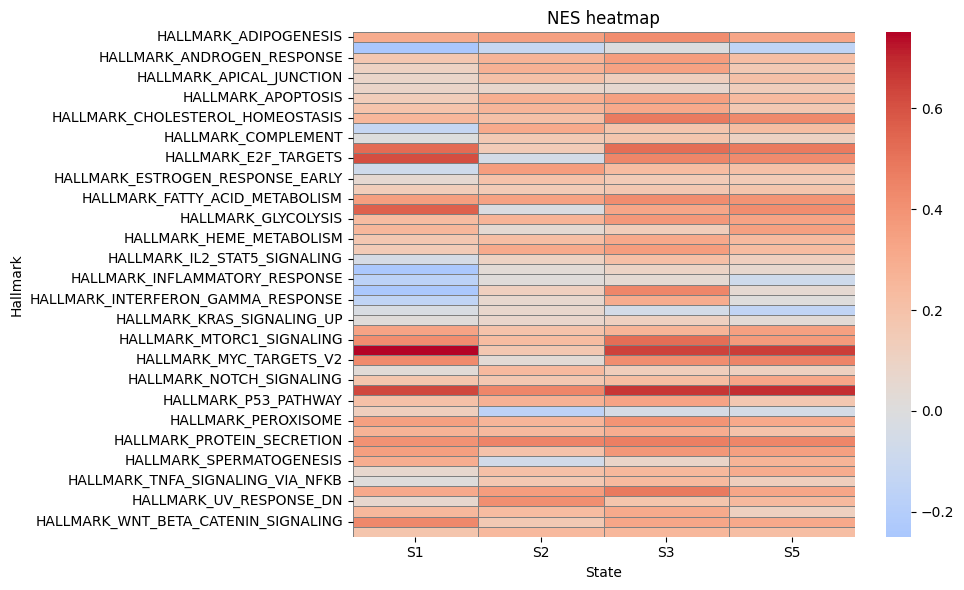

In [166]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(
    heat_df,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor="gray"
)
plt.xlabel("State")
plt.ylabel("Hallmark")
plt.title("NES heatmap")
plt.tight_layout()
plt.show()

For more outputs from ssgsea, please see [gseapy](https://gseapy.readthedocs.io/en/latest/gseapy_example.html) documentation.

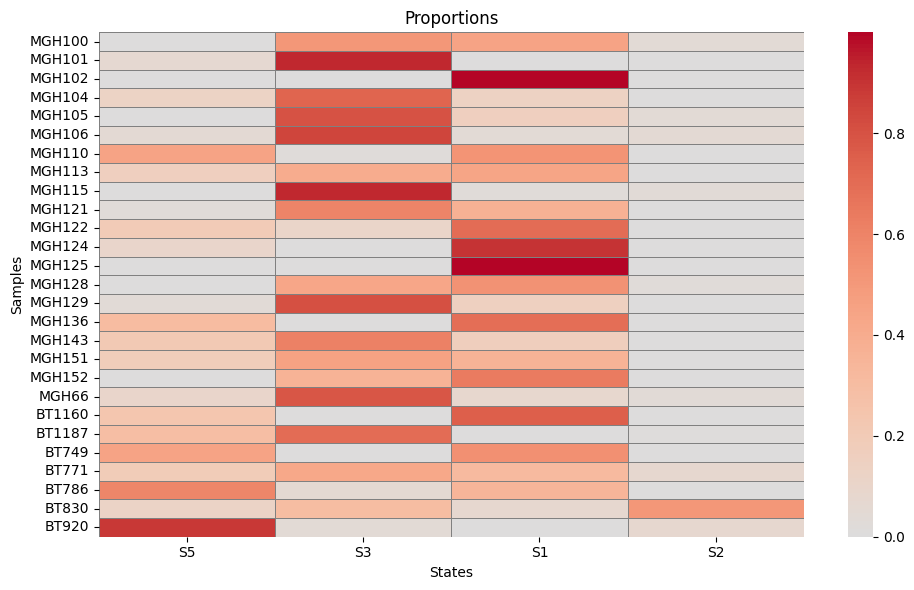

In [178]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    malignant_proportions,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor="gray"
)
plt.xlabel("States")
plt.ylabel("Samples")
plt.title("Proportions")
plt.tight_layout()
plt.show()